# Conditional Flow Matching

So far we've learned to sample from **unconditional target distributions** $P(X)$. In this notebook, we extend flow matching to **conditional generation** $P(X|Y)$, where we want to sample from the distribution of $X$ given a specific value of $Y$.

## Overview

**Conditional generation** is central to many applications:
- **Class-conditional image generation:** Generate images of a specific class (e.g., "dogs")
- **Inverse problems:** Sample from the posterior $P(X|Y=\text{observation})$
- **Controlled generation:** Specify attributes or constraints for generated samples

**Key Questions:**
1. How do we modify the network architecture to condition on $Y$?
2. Can we use optimal transport in the conditional setting?
3. How do we ensure good conditionals $P(X|Y=y)$ for each class $y$?

We'll answer these questions using a toy example with **3 classes** where each class has **multiple modes** .

## Setup for Google Colab

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("Installing dependencies...")
    !pip install -q pot geomloss

    # Download fm_utils.py
    import urllib.request
    url = "https://raw.githubusercontent.com/JChemseddine/fm_tutorial/main/fm_utils.py"
    urllib.request.urlretrieve(url, "fm_utils.py")
    print("✓ Setup complete!")
else:
    # Local development - add parent directory to path
    import sys
    sys.path.insert(0, '..')

Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.4 MB/s eta 0:00:00
✓ Setup complete!


## Imports

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from geomloss import SamplesLoss

from fm_utils import (
    DEVICE,
    set_seed,
    SinusoidalTimeEmbedding,
    update_ema,
    compute_ema,
    plot_source_target_trajectories,
)

plt.style.use("seaborn-v0_8")
torch.set_default_dtype(torch.float32)

# Define distance metric for comparing distributions
energy_loss = SamplesLoss("energy")

set_seed(42)
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Dataset: Multimodal 3-Class GMM

We define a **labeled Gaussian mixture with multimodal class posteriors** where:
- 9 Gaussian components arranged in a 3×3 grid
- **3 classes** with multiple modes per class:
  - **Class 0**: Upper-left and upper-right corners (2 modes)
  - **Class 1**: Bottom-left and bottom-right corners (2 modes)
  - **Class 2**: Center + 4 edge midpoints (5 modes)
- **Equal class weights**: Each class has probability $1/3$



In [3]:
class LabeledGridGMM3Multimodal:
    """Three-class GMM with multimodal posteriors for each class.

    Class structure (9 modes total):
    - Class 0: Upper-left & upper-right (2 modes) - multimodal
    - Class 1: Bottom-left & bottom-right (2 modes) - multimodal
    - Class 2: Center + 4 edge midpoints (5 modes) - highly multimodal
    """

    def __init__(self, spacing: float = 1.0, var: float = 0.01):
        coords = (-float(spacing), 0.0, float(spacing))

        # All 9 positions in the grid
        all_positions = [(x, y) for x in coords for y in coords]

        # Map grid positions to class labels
        # Class 0: upper-left (0,2) and upper-right (2,2)
        # Class 1: bottom-left (0,0) and bottom-right (2,0)
        # Class 2: all others (center and edges)
        position_to_class = {
            (coords[0], coords[2]): 0,  # upper-left
            (coords[2], coords[2]): 0,  # upper-right
            (coords[0], coords[0]): 1,  # bottom-left
            (coords[2], coords[0]): 1,  # bottom-right
            (coords[1], coords[1]): 2,  # center
            (coords[0], coords[1]): 2,  # middle-left
            (coords[2], coords[1]): 2,  # middle-right
            (coords[1], coords[0]): 2,  # bottom-center
            (coords[1], coords[2]): 2,  # top-center
        }

        # Group positions by class
        self.class_to_positions = {0: [], 1: [], 2: []}
        for pos in all_positions:
            class_id = position_to_class[pos]
            self.class_to_positions[class_id].append(pos)

        # Convert to tensors
        self.means = torch.tensor(all_positions, dtype=torch.get_default_dtype())
        self.var = var
        self.num_classes = 3

        # Store mapping for sampling
        self.position_to_class = position_to_class
        self.class_sizes = [len(self.class_to_positions[i]) for i in range(3)]

    def sample(self, n: int, device=None, dtype=None):
        """Sample (x, y) pairs where y ∈ {0,1,2} is the class label."""
        device = device or DEVICE
        dtype = dtype or torch.get_default_dtype()

        # Equal probability for each class (not each mode!)
        labels = torch.randint(0, self.num_classes, (n,), device=device)

        # For each sample, pick a random mode within its class
        mode_indices = torch.zeros(n, dtype=torch.long, device=device)
        for class_id in range(self.num_classes):
            mask = labels == class_id
            n_class = mask.sum().item()
            if n_class > 0:
                # Randomly pick one of the modes for this class
                class_positions = self.class_to_positions[class_id]
                # Get global indices of modes in this class
                global_mode_indices = [i for i, pos in enumerate(self.means.tolist())
                                      if tuple(pos) in class_positions]
                # Randomly select from these modes
                selected = torch.tensor(global_mode_indices, device=device)[
                    torch.randint(0, len(global_mode_indices), (n_class,), device=device)
                ]
                mode_indices[mask] = selected

        # Sample from corresponding Gaussians
        means = self.means.to(device=device, dtype=dtype)
        noise = torch.randn(n, 2, device=device, dtype=dtype) * math.sqrt(self.var)
        x = means[mode_indices] + noise

        return x, labels

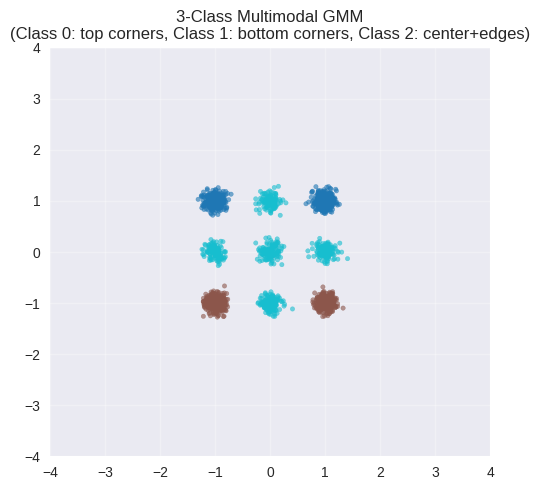

In [4]:
gmm = LabeledGridGMM3Multimodal()
samples, labels = gmm.sample(2000)

plt.figure(figsize=(5, 5))
scatter = plt.scatter(samples[:, 0].cpu(), samples[:, 1].cpu(),
                     c=labels.cpu(), cmap='tab10', s=10, alpha=0.6, vmin=0, vmax=2)
#plt.colorbar(scatter, label='Class', ticks=[0, 1, 2])
plt.title('3-Class Multimodal GMM\n(Class 0: top corners, Class 1: bottom corners, Class 2: center+edges)')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Conditional Velocity Network

To predict velocities conditioned on class labels, we modify the network architecture:

**Key modification:** Convert class labels to **one-hot encodings** and concatenate directly with the spatial position $x$.

$$
v_t^\theta(t, x, y) = \text{MLP}(t, [x; \text{one\_hot}(y)])
$$

where $[\cdot ; \cdot]$ denotes concatenation and $\text{one\_hot}(y) \in \{0,1\}^K$ is the one-hot encoding of class $y$.

For example, with 3 classes:
- Class 0: $[1, 0, 0]$
- Class 1: $[0, 1, 0]$
- Class 2: $[0, 0, 1]$

**Why one-hot encoding?** One-hot encoding treats classes as categorical variables with no inherent ordering, unlike integer encoding (0, 1, 2) which would imply that class 2 > class 1. This prevents the network from learning spurious relationships based on the arbitrary numerical values assigned to classes.

This is the same MLP architecture as before, but with an augmented input dimension ($D + K$ instead of $D$).

In [5]:
class ConditionalVelocityMLP(nn.Module):
    """Velocity network conditioned on class labels using one-hot encoding."""

    def __init__(
        self,
        input_dim: int = 2,
        num_classes: int = 3,
        hidden_dim: int = 128,
        time_embed_dim: int = 64,
        num_layers: int = 3,
    ):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_embed_dim)
        self.num_classes = num_classes

        # Build network: input is [x, one_hot(y), time_embedding]
        layers = []
        layers.append(nn.Linear(input_dim + num_classes + time_embed_dim, hidden_dim))
        layers.append(nn.SiLU())

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())

        layers.append(nn.Linear(hidden_dim, input_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, t: torch.Tensor, x: torch.Tensor, y: torch.Tensor):
        """
        Args:
            t: Time (B, 1) or (B,)
            x: Spatial positions (B, D)
            y: Class labels (B,) integers in {0, ..., num_classes-1}

        Returns:
            Velocity field (B, D)
        """
        if t.dim() == 1:
            t = t.unsqueeze(-1)

        t_emb = self.time_embed(t)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)

        # Convert class labels to one-hot encoding
        y_onehot = torch.nn.functional.one_hot(y, self.num_classes).float()  # (B, num_classes)

        # Concatenate x, one-hot class, and time embedding
        h = torch.cat([x, y_onehot, t_emb], dim=-1)
        return self.net(h)

## 3. Conditional Flow Matching with Random Pairing

We first train with **random pairing** as a baseline.

### Training Objective

For each data sample $(x_0, y_0) \sim P(X, Y)$ (where $x_0$ is from the data distribution) and latent $x_1 \sim \mathcal{N}(0, I)$ (where $x_1$ is the noise), we:
1. Assign the latent the same label: $y_1 = y_0$
2. Form the straight-line path: $x_t = (1-t)x_0 + t \cdot x_1$
3. Train to predict velocity: $v_t^\theta(t, x_t, y_0) \approx x_1 - x_0$

The loss is:
$$
\mathcal{L}(\theta) = \mathbb{E}_{t, (x_0, y_0), x_1} \Big[ \| v_t^\theta(t, x_t, y_0) - (x_1 - x_0) \|^2 \Big]
$$

In [6]:
def train_conditional_flow_random(config):
    """Train conditional flow matching with random pairing."""
    set_seed(config['seed'])

    model = ConditionalVelocityMLP(
        num_classes=config['num_classes']
    ).to(DEVICE)
    ema_model = ConditionalVelocityMLP(
        num_classes=config['num_classes']
    ).to(DEVICE)
    ema_model.load_state_dict(model.state_dict())

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    losses = []

    for step in range(config['steps']):
        # Sample data with labels: (x_0, y_0) ~ P(X, Y)
        x_0, y_0 = config['target_sampler'](config['batch_size'])

        # Sample latents: x_1 ~ N(0, I), keep same labels
        x_1 = torch.randn(config['batch_size'], 2, device=DEVICE)
        y_1 = y_0  # Latents have same labels as data

        # Linear interpolation
        t = torch.rand(config['batch_size'], 1, device=DEVICE)
        x_t = (1.0 - t) * x_0 + t * x_1
        velocity_target = x_1 - x_0

        # Predict velocity conditioned on class
        pred = model(t, x_t, y_1)
        loss = ((pred - velocity_target) ** 2).sum(dim=1).mean()

        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), config['grad_clip'])
        optimizer.step()
        update_ema(ema_model, model, config.get('ema_decay', 0.9))

        losses.append(loss.detach().cpu().item())
        if (step + 1) % config['log_every'] == 0:
            print(f"step {step + 1:5d} | loss = {losses[-1]:.6f}")

    return {
        'model': model,
        'ema': ema_model,
        'losses': losses,
        'config': config,
    }

Training Conditional FM with Random Pairing...
step  1000 | loss = 1.929154
step  2000 | loss = 1.488574
step  3000 | loss = 1.445463
step  4000 | loss = 1.391136
step  5000 | loss = 1.326256
step  6000 | loss = 1.629179
step  7000 | loss = 1.441745
step  8000 | loss = 1.370556
step  9000 | loss = 1.590231
step 10000 | loss = 1.413170


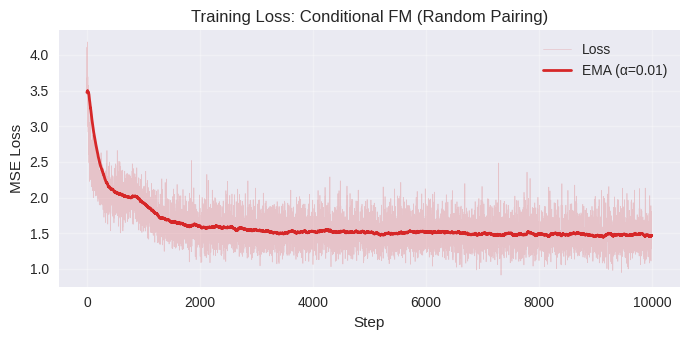

In [7]:
# Configuration
config_random = {
    'target_sampler': lambda n: gmm.sample(n, device=DEVICE),
    'num_classes': 3,
    'steps': 10_000,
    'batch_size': 128,
    'lr': 1e-3,
    'seed': 42,
    'grad_clip': 1.0,
    'log_every': 1000,
}

print("Training Conditional FM with Random Pairing...")
run_random = train_conditional_flow_random(config_random)

# Plot loss with EMA
plt.figure(figsize=(7, 3.5))
plt.plot(run_random['losses'], color='#D62728', alpha=0.2, linewidth=0.5, label='Loss')
plt.plot(compute_ema(run_random['losses'], alpha=0.01), color='#D62728', linewidth=2, label='EMA (α=0.01)')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.title('Training Loss: Conditional FM (Random Pairing)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Conditional Sampling and Visualization

To sample from the conditional distribution $P(X|Y=y)$, we:
1. Start with Gaussian latents $z \sim \mathcal{N}(0, I)$
2. Assign all latents the same class label $y$
3. Integrate the velocity field backwards from $t=1$ to $t=0$

This gives us samples from the learned conditional $P_\theta(X|Y=y)$.

We'll visualize results in two ways:
- **Sample comparison**: Generated samples vs ground truth (all classes color-coded)
- **Flow trajectories**: Paths taken by latents as they flow to each class

In [8]:
def sample_conditional(model, y, n_samples, flow_T=1.0, steps=150, device=DEVICE, latents=None, return_path=False):
    """
    Sample from the conditional distribution P(X|Y=y).

    Args:
        model: Trained ConditionalVelocityMLP
        y: Class label (integer)
        n_samples: Number of samples to generate
        flow_T: Flow time (default 1.0)
        steps: Number of ODE integration steps
        device: Device to run on
        latents: Optional pre-generated latents (if None, will sample from N(0,I))
        return_path: If True, return full trajectory

    Returns:
        Samples (n_samples, 2) or trajectories (steps, n_samples, 2) if return_path=True
    """
    # Start from Gaussian latents (or use provided ones)
    if latents is None:
        latents = torch.randn(n_samples, 2, device=device)

    y_repeated = torch.full((n_samples,), y, dtype=torch.long, device=device)

    with torch.no_grad():
        times = torch.linspace(flow_T, 0.0, steps, device=device)
        x = latents
        if return_path:
            trajectory = [x.clone()]

        for i in range(len(times) - 1):
            t_curr = times[i].expand(n_samples, 1)
            dt = times[i + 1] - times[i]
            velocity = model(t_curr, x, y_repeated)
            x = x + dt * velocity
            if return_path:
                trajectory.append(x.clone())

        if return_path:
            return torch.stack(trajectory, dim=0)

    return x


def sample_all_classes(model, n_per_class=400, flow_T=1.0, steps=150, num_classes=3, device=DEVICE):
    """Sample from all classes and return combined samples with labels."""
    all_samples = []
    all_labels = []

    for class_id in range(num_classes):
        samples = sample_conditional(model, y=class_id, n_samples=n_per_class,
                                    flow_T=flow_T, steps=steps, device=device)
        labels = torch.full((n_per_class,), class_id, dtype=torch.long, device=device)
        all_samples.append(samples)
        all_labels.append(labels)

    return torch.cat(all_samples, dim=0), torch.cat(all_labels, dim=0)


def compute_per_class_metrics(model, n_samples=2000, num_classes=3, gt_samples_dict=None):
    """
    Compute Energy distance for each class posterior separately.

    Args:
        model: Trained model
        n_samples: Number of samples per class
        num_classes: Number of classes
        gt_samples_dict: Optional dict {class_id: ground_truth_samples}. If None, generates fresh GT.

    Returns:
        dict: {class_id: energy_distance}
    """
    metrics = {}

    # Generate ground truth if not provided
    if gt_samples_dict is None:
        gt_samples_dict = {}
        for class_id in range(num_classes):
            gt_samples = []
            while len(gt_samples) < n_samples:
                batch_samples, batch_labels = gmm.sample(n_samples, device=DEVICE)
                mask = batch_labels == class_id
                gt_samples.append(batch_samples[mask])
            gt_samples_dict[class_id] = torch.cat(gt_samples, dim=0)[:n_samples]

    with torch.no_grad():
        for class_id in range(num_classes):
            # Generate samples for this class
            gen_samples = sample_conditional(model, y=class_id, n_samples=n_samples,
                                           flow_T=1.0, steps=150, device=DEVICE)

            # Use provided or generated ground truth
            gt_samples = gt_samples_dict[class_id]

            # Compute Energy distance
            energy_dist = energy_loss(gen_samples, gt_samples).item()
            metrics[class_id] = energy_dist

    return metrics


def compare_with_ground_truth(model, n_per_class=400, title_prefix=""):
    """Compare generated samples with ground truth in side-by-side plots."""
    # Generate samples
    gen_samples, gen_labels = sample_all_classes(model, n_per_class=n_per_class)
    gen_samples_np = gen_samples.cpu().numpy()
    gen_labels_np = gen_labels.cpu().numpy()

    # Sample ground truth
    gt_samples, gt_labels = gmm.sample(n_per_class * 3)
    gt_samples_np = gt_samples.cpu().numpy()
    gt_labels_np = gt_labels.cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Ground truth
    axes[0].scatter(gt_samples_np[:, 0], gt_samples_np[:, 1],
                    c=gt_labels_np, cmap='tab10', s=8, alpha=0.6,
                    edgecolors='none', vmin=0, vmax=2)
    axes[0].set_title('Ground Truth', fontsize=14)
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect('equal')

    # Generated
    axes[1].scatter(gen_samples_np[:, 0], gen_samples_np[:, 1],
                    c=gen_labels_np, cmap='tab10', s=8, alpha=0.6,
                    edgecolors='none', vmin=0, vmax=2)
    axes[1].set_title(f'{title_prefix}Generated', fontsize=14)
    axes[1].set_xlim(-3, 3)
    axes[1].set_ylim(-3, 3)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect('equal')

    plt.tight_layout()
    plt.show()


def visualize_conditional_trajectories(model, class_id=0, n_samples=512, flow_T=1.0,
                                      steps=60, title=None):
    """
    Visualize trajectories for a FIXED class using plot_source_target_trajectories.

    Args:
        model: Trained ConditionalVelocityMLP
        class_id: Which class to visualize (default: 0, students can change it)
        n_samples: Number of latent samples
        flow_T: Flow time
        steps: Number of ODE integration steps
        title: Plot title (optional)
    """
    # Sample latent points (from Gaussian) - ONCE!
    latents = torch.randn(n_samples, 2, device=DEVICE)

    # Sample target ground truth from all classes for background
    target_samples, _ = gmm.sample(2048, device=DEVICE)

    # Generate trajectories for the FIXED class, using the SAME latents
    trajectories = sample_conditional(
        model, y=class_id, n_samples=n_samples,
        flow_T=flow_T, steps=steps, device=DEVICE,
        latents=latents,  # Pass the latents so we use the same ones!
        return_path=True
    )

    # Use the standard plotting function from fm_utils
    fig, ax = plt.subplots(figsize=(7, 6))

    if title is None:
        title = f'Conditional Flow Trajectories (Class {class_id})'

    plot_source_target_trajectories(
        source=latents,
        trajectories=trajectories,
        background=target_samples,
        title=title,
        ax=ax,
        max_paths=64,
        latent_color="#000000",
        endpoint_color="#1f77b4",
        path_color="#90EE90"
    )

    # Move legend outside the plot area to avoid blocking content
    ax.legend(frameon=True, loc='upper left', bbox_to_anchor=(1.02, 1.0),
              fancybox=True, shadow=True)

    plt.tight_layout()
    plt.show()

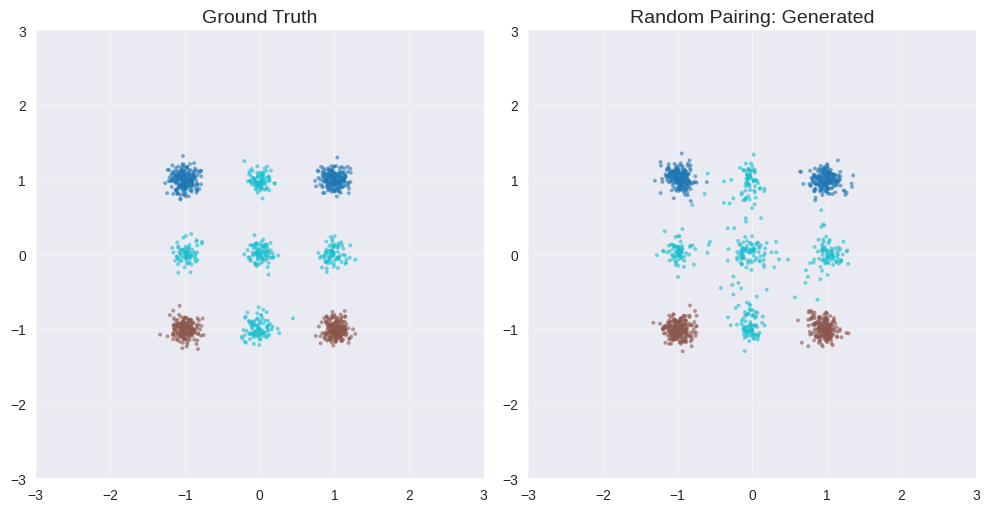

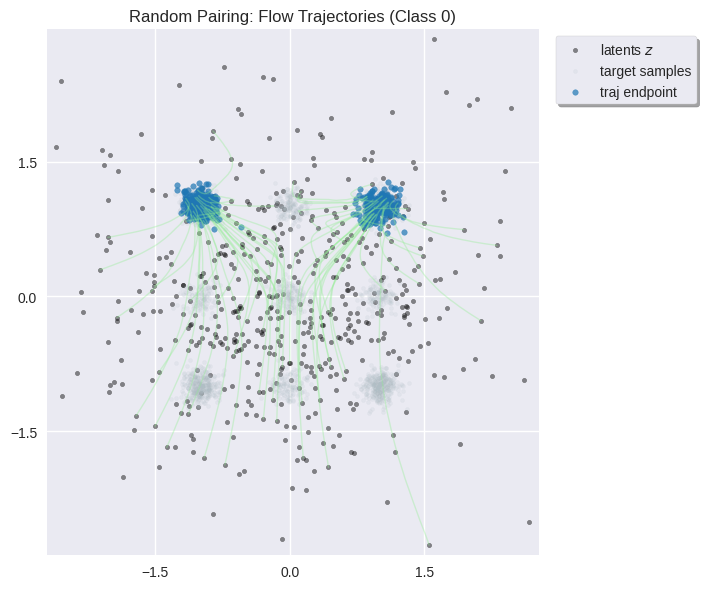

In [9]:
# Visualize random pairing results
compare_with_ground_truth(run_random['ema'], n_per_class=400, title_prefix="Random Pairing: ")

# Visualize trajectories for class 0 (students can change this!)
visualize_conditional_trajectories(run_random['ema'], class_id=0, n_samples=512,
                                   title="Random Pairing: Flow Trajectories (Class 0)")

## 5. Conditional Wasserstein Distances

### Motivation: Why Do We Need Conditional OT?

In unconditional flow matching, we learned to transport from $\mu_0$ (source) to $\mu_1$ (target). Random pairing works, but OT pairing gives us straighter paths and better convergence.

Now we have **labeled data**: each sample comes with a class label $y \in \{0, 1, 2\}$. We want to learn good **conditional distributions** $P(X|Y=y)$ for each class.

**The challenge:** Standard OT on spatial positions alone doesn't know about class labels! It might pair:
- A sample from class 0 with a latent that should go to class 1
- This creates inefficient transport that doesn't respect class structure
- **Even worse with multimodal posteriors**: Within a single class, we have multiple modes (e.g., Class 0 has modes at upper-left and upper-right corners). Random pairing might send a latent from the upper-left to the upper-right mode, crossing through the center unnecessarily.

**Key theoretical insight:** The "chain rule" that works for KL divergence:
$$
\mathrm{KL}(P_{Y,X}, Q_{Y,X}) = \mathbb{E}_{y\sim P_Y}[\mathrm{KL}(P_{X|Y=y}, Q_{X|Y=y})]
$$

**does NOT hold** for Wasserstein distances!

### Solution: Conditional Wasserstein Distance... for us the regularized version

Instead of the standard cost $c(x_1, x_2) = \|x_1 - x_2\|^2$, we use:
$$
d_\beta((y_1, x_1), (y_2, x_2)) = \|x_1 - x_2\|^2 + \beta \|y_1 - y_2\|^2
$$

**Implementation via one-hot encoding:**
- Represent class $y$ as one-hot vector: $e_y \in \{0,1\}^K$ where $K=3$
- Augment features: $(x, \beta \cdot e_y)$
- Compute standard Euclidean distance in this augmented space

**Effect of $\beta$:**
- $\beta = 0$: Standard OT (no class awareness) - but still better than random within each class!
- $\beta > 0$: Encourages pairing samples with the **same class**
- $\beta \to \infty$: Converges to the conditional Wasserstein distance from the lecture



## 6. Conditional OT Pairing Implementation

We implement Y-penalized OT using **one-hot concatenation**:

$$
\text{Cost}_{ij} = \|x_i^0 - x_j^1\|^2 + \beta^2 \|e_{y_i^0} - e_{y_j^1}\|^2
$$

where $e_y$ is the one-hot encoding of class $y \in \{0, 1, 2\}$.

This is equivalent to computing Euclidean distance in the augmented space $(x, \beta \cdot e_y)$.

In [10]:
def conditional_minibatch_ot_pairing(x0, y0, x1, y1, beta=50.0, num_classes=3):
    """
    Compute OT pairing with Y-penalized cost using one-hot concatenation.

    Cost: d²((y₀,x₀), (y₁,x₁)) = ||x₀ - x₁||² + ||β·one_hot(y₀) - β·one_hot(y₁)||²

    Args:
        x0: Data points (B, D)
        y0: Data class labels (B,) integers
        x1: Latent points (B, D)
        y1: Latent class labels (B,) integers
        beta: Penalty weight for class mismatch (default: 50.0)
        num_classes: Number of classes (default: 3)

    Returns:
        indices: (B,) permutation indices so x1[indices] is optimally paired with x0
        transport_plan: (B, B) OT plan
    """
    import ot as pot_lib

    device = x0.device
    batch_size = x0.shape[0]

    with torch.no_grad():
        # Convert labels to one-hot
        y0_onehot = torch.nn.functional.one_hot(y0, num_classes).float()  # (B, K)
        y1_onehot = torch.nn.functional.one_hot(y1, num_classes).float()  # (B, K)

        # Augment features with scaled one-hot
        x0_aug = torch.cat([x0, beta * y0_onehot], dim=1)  # (B, D+K)
        x1_aug = torch.cat([x1, beta * y1_onehot], dim=1)  # (B, D+K)

        # Compute cost in augmented space (squared Euclidean)
        C = torch.cdist(x0_aug, x1_aug, p=2).pow(2).cpu().numpy()

        # Solve OT
        a = pot_lib.unif(batch_size)
        b = pot_lib.unif(batch_size)
        P = pot_lib.emd(a, b, C)

        P_torch = torch.tensor(P, dtype=torch.float32, device=device)

        # Extract indices: for each x0[i], find which x1[j] is matched to it
        # So we reorder x1 to match x0
        indices = torch.argmax(P_torch, dim=1)

    return indices, P_torch

## 7. Conditional Flow Matching with OT Pairing

Now we train with **Y-penalized OT pairing**.

**Key difference from random pairing:**
1. Sample data $(x_0, y_0) \sim P(X, Y)$
2. Sample latents $x_1 \sim \mathcal{N}(0, I)$, reuse the same labels $y_1 = y_0$
3. **Compute optimal transport** with Y-penalized cost to find pairing
4. Reorder $x_1,y_1$ according to OT plan to match $x_0,y_0$
5. Train on paired samples

In [11]:
def train_conditional_flow_ot(config, beta=50.0):
    """Train conditional flow matching with Y-penalized OT pairing."""
    set_seed(config['seed'])

    model = ConditionalVelocityMLP(
        num_classes=config['num_classes']
    ).to(DEVICE)
    ema_model = ConditionalVelocityMLP(
        num_classes=config['num_classes']
    ).to(DEVICE)
    ema_model.load_state_dict(model.state_dict())

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    losses = []
    pairing_costs = []

    for step in range(config['steps']):
        # Sample data with labels: (x_0, y_0) ~ P(X, Y)
        x_0, y_0 = config['target_sampler'](config['batch_size'])

        # Sample latents with same labels
        x_1 = torch.randn(config['batch_size'], 2, device=DEVICE)
        y_1 = y_0

        # Apply conditional OT pairing
        indices, transport_plan = conditional_minibatch_ot_pairing(
            x_0, y_0, x_1, y_1,
            beta=beta,
            num_classes=config['num_classes']
        )

        # Reorder x_1 and y_1 according to OT
        x_1 = x_1[indices]
        y_1 = y_1[indices]

        # Compute spatial pairing cost (for monitoring)
        cost_matrix = torch.cdist(x_0, x_1, p=2).pow(2)
        pairing_costs.append(float((transport_plan * cost_matrix).sum().item()))

        # Linear interpolation
        t = torch.rand(config['batch_size'], 1, device=DEVICE)
        x_t = (1.0 - t) * x_0 + t * x_1
        velocity_target = x_1 - x_0

        # Predict velocity conditioned on labels
        pred = model(t, x_t, y_1)
        loss = ((pred - velocity_target) ** 2).sum(dim=1).mean()

        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), config['grad_clip'])
        optimizer.step()
        update_ema(ema_model, model, config.get('ema_decay', 0.9))

        losses.append(loss.detach().cpu().item())
        if (step + 1) % config['log_every'] == 0:
            print(f"step {step + 1:5d} | loss = {losses[-1]:.6f} | OT cost = {pairing_costs[-1]:.4f}")

    return {
        'model': model,
        'ema': ema_model,
        'losses': losses,
        'pairing_costs': pairing_costs,
        'config': config,
        'beta': beta,
    }

## 8. Comparison: Random vs OT Pairing

Now let's compare the results from random pairing vs Y-penalized OT pairing (with β=50).

We'll examine:
1. **Sample quality**: How well do generated samples match the ground truth?
2. **Flow trajectories**: Are the paths straighter with OT pairing?

In [12]:
config_ot = {
    'target_sampler': lambda n: gmm.sample(n, device=DEVICE),
    'num_classes': 3,
    'steps': 10_000,
    'batch_size': 128,
    'lr': 1e-3,
    'seed': 42,
    'grad_clip': 1.0,
    'log_every': 1000,
}

print("Training Conditional FM with OT Pairing (β=50)...")
run_ot = train_conditional_flow_ot(config_ot, beta=50.0)

Training Conditional FM with OT Pairing (β=50)...
step  1000 | loss = 0.190927 | OT cost = 3.9587
step  2000 | loss = 0.149809 | OT cost = 3.2414
step  3000 | loss = 0.175256 | OT cost = 3.3247
step  4000 | loss = 0.185936 | OT cost = 3.1116
step  5000 | loss = 0.133182 | OT cost = 3.1812
step  6000 | loss = 0.150465 | OT cost = 3.7287
step  7000 | loss = 0.102070 | OT cost = 3.5522
step  8000 | loss = 0.138325 | OT cost = 3.3569
step  9000 | loss = 0.154461 | OT cost = 3.6746
step 10000 | loss = 0.086791 | OT cost = 3.7182


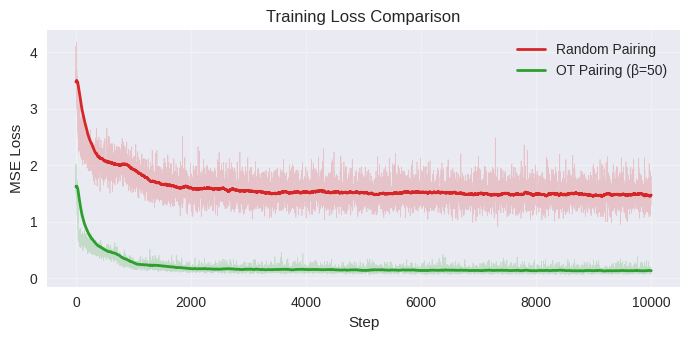

In [13]:
# Compare losses
fig, ax = plt.subplots(figsize=(7, 3.5))

# Random pairing
ax.plot(run_random['losses'], color='#D62728', alpha=0.2, linewidth=0.5)
ax.plot(compute_ema(run_random['losses'], alpha=0.01), label='Random Pairing', color='#D62728', linewidth=2)

# OT pairing
ax.plot(run_ot['losses'], color='#2CA02C', alpha=0.2, linewidth=0.5)
ax.plot(compute_ema(run_ot['losses'], alpha=0.01), label='OT Pairing (β=50)', color='#2CA02C', linewidth=2)

ax.set_xlabel('Step')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Random Pairing:


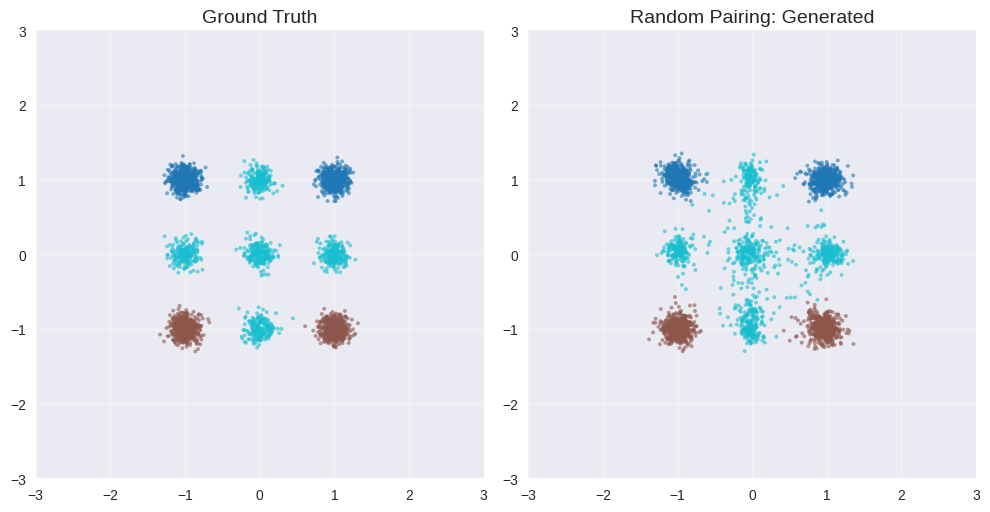


OT Pairing (β=50):


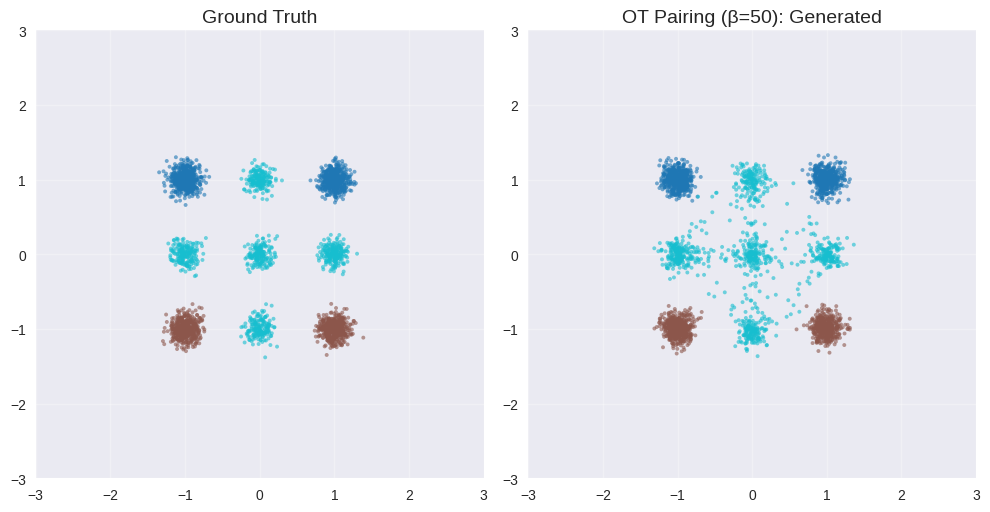


Per-Class Energy Distance (lower is better)

Generating ground truth samples...

Computing metrics for Random Pairing...
Computing metrics for OT Pairing...

------------------------------------------------------------
Class           Random               OT (β=50)            Improvement    
------------------------------------------------------------
0               0.000580             0.000375               35.4%
1               0.002159             0.000559               74.1%
2               0.002071             0.000506               75.6%
------------------------------------------------------------
Average         0.001603             0.000480               70.1%

Key insight: OT pairing improves quality for each class posterior,
especially beneficial for multimodal posteriors (Class 0, 1, 2 all improve).


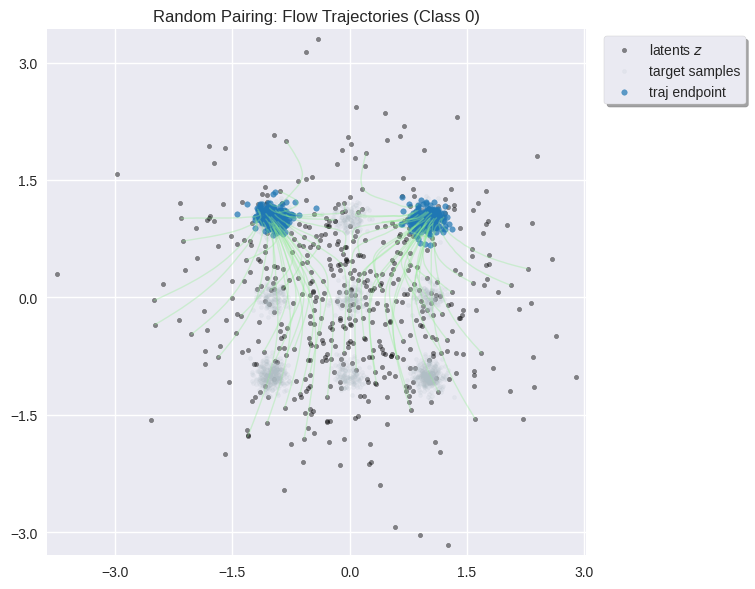

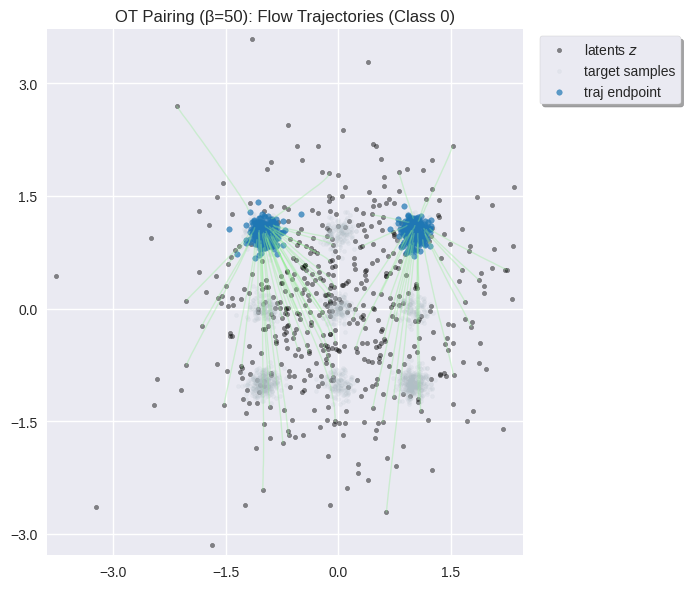

In [14]:
# Compare samples: Random vs OT Pairing
print("Random Pairing:")
compare_with_ground_truth(run_random['ema'], n_per_class=1000, title_prefix="Random Pairing: ")

print("\nOT Pairing (β=50):")
compare_with_ground_truth(run_ot['ema'], n_per_class=1000, title_prefix="OT Pairing (β=50): ")

# Compute per-class metrics
print("\n" + "="*60)
print("Per-Class Energy Distance (lower is better)")
print("="*60)

# Generate ground truth ONCE for fair comparison
print("\nGenerating ground truth samples...")
set_seed(123)  # Set seed for reproducible ground truth
gt_samples_dict = {}
n_samples = 2000
for class_id in range(3):
    gt_samples = []
    while len(gt_samples) < n_samples:
        batch_samples, batch_labels = gmm.sample(n_samples, device=DEVICE)
        mask = batch_labels == class_id
        gt_samples.append(batch_samples[mask])
    gt_samples_dict[class_id] = torch.cat(gt_samples, dim=0)[:n_samples]

print("\nComputing metrics for Random Pairing...")
metrics_random = compute_per_class_metrics(run_random['ema'], n_samples=n_samples, gt_samples_dict=gt_samples_dict)

print("Computing metrics for OT Pairing...")
metrics_ot = compute_per_class_metrics(run_ot['ema'], n_samples=n_samples, gt_samples_dict=gt_samples_dict)

print("\n" + "-"*60)
print(f"{'Class':<15} {'Random':<20} {'OT (β=50)':<20} {'Improvement':<15}")
print("-"*60)
for class_id in range(3):
    random_val = metrics_random[class_id]
    ot_val = metrics_ot[class_id]
    improvement = ((random_val - ot_val) / random_val) * 100
    print(f"{class_id:<15} {random_val:<20.6f} {ot_val:<20.6f} {improvement:>6.1f}%")

# Compute averages
avg_random = np.mean([metrics_random[i] for i in range(3)])
avg_ot = np.mean([metrics_ot[i] for i in range(3)])
avg_improvement = ((avg_random - avg_ot) / avg_random) * 100
print("-"*60)
print(f"{'Average':<15} {avg_random:<20.6f} {avg_ot:<20.6f} {avg_improvement:>6.1f}%")
print("="*60)
print("\nKey insight: OT pairing improves quality for each class posterior,")
print("especially beneficial for multimodal posteriors (Class 0, 1, 2 all improve).")

# Compare trajectories (class 0, students can change this!)
visualize_conditional_trajectories(run_random['ema'], class_id=0, n_samples=512,
                                   title="Random Pairing: Flow Trajectories (Class 0)")

visualize_conditional_trajectories(run_ot['ema'], class_id=0, n_samples=512,
                                   title="OT Pairing (β=50): Flow Trajectories (Class 0)")

## 9. Effect of β (Ablation Study)

How does the penalty weight $\beta$ affect class separation?

We train models with different values of $\beta$ and visualize the results.

In [ ]:
betas = [0.0, 0.3, 0.5, 5.0]
runs_beta = {}

for beta in betas:
    print(f"\n{'='*60}")
    print(f"Training with β = {beta}")
    print('='*60)
    runs_beta[beta] = train_conditional_flow_ot(config_ot, beta=beta)


Training with β = 0.0
step  1000 | loss = 0.111928 | OT cost = 3.9744
step  2000 | loss = 0.103670 | OT cost = 3.2738
step  3000 | loss = 0.137098 | OT cost = 3.5136
step  4000 | loss = 0.113278 | OT cost = 3.2779
step  5000 | loss = 0.089934 | OT cost = 2.9612
step  6000 | loss = 0.107427 | OT cost = 3.8491
step  7000 | loss = 0.077921 | OT cost = 3.5750
step  8000 | loss = 0.085344 | OT cost = 3.2915
step  9000 | loss = 0.122467 | OT cost = 3.6970


In [ ]:
# Visualize all β values - samples comparison
fig, axes = plt.subplots(1, len(betas), figsize=(16, 3.5))

for idx, beta in enumerate(betas):
    # Sample from all classes
    samples, labels = sample_all_classes(runs_beta[beta]['ema'], n_per_class=200)
    samples_np = samples.cpu().numpy()
    labels_np = labels.cpu().numpy()

    scatter = axes[idx].scatter(samples_np[:, 0], samples_np[:, 1],
                               c=labels_np, cmap='tab10', s=4, alpha=0.6,
                               edgecolors='none', vmin=0, vmax=2)
    axes[idx].set_title(f'β={beta}', fontsize=12, fontweight='bold')
    axes[idx].set_xlim(-3, 3)
    axes[idx].set_ylim(-3, 3)
    axes[idx].set_aspect('equal')
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].set_ylabel('x2')
    axes[idx].set_xlabel('x1')


plt.suptitle('Effect of β on Class Separation (Multimodal Posteriors)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Visualize trajectories for extreme cases (class 0, students can change this!)
print("\nTrajectories for β=0.0 (no class penalty):")
visualize_conditional_trajectories(runs_beta[0.0]['ema'], class_id=0, n_samples=512,
                                   title="β=0.0: No Class Penalty (Class 0)")

print("\nTrajectories for β=5.0 (strong class penalty):")
visualize_conditional_trajectories(runs_beta[5.0]['ema'], class_id=0, n_samples=512,
                                   title="β=5.0: Strong Class Penalty (Class 0)")

## 10. Remark
**The same computational considerations from Notebook 02 apply here.**

For high-dimensional problems with realistic networks:
- Training time is dominated by backpropagation through the neural network
- The OT computation is typically a fraction of step time
- The benefits (faster convergence, straighter paths, lower NFE) generally outweigh the cost



## 11. Summary

**Conditional generation** requires class-aware networks that learn $P(X|Y=y)$ for each class $y$.

**Y-penalized OT** extends standard OT benefits to conditional settings:
- Faster convergence (fewer training steps)
- Straighter flow paths (lower NFE at inference)
- Better sample quality (tighter clusters, clearer separation)


**Applications:** Class-conditional image generation, Bayesian posterior sampling, physics-informed models with boundary conditions.